Train dir: /kaggle/input/datasets/salader/dogsvscats/train 
Test dir : /kaggle/input/datasets/salader/dogsvscats/test


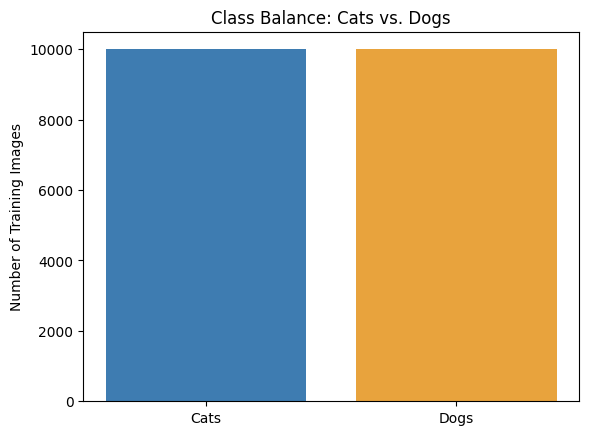

Found 20000 files belonging to 2 classes.
Using 16000 files for training.


2026-10-02 16:08:06.703813: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Found 5000 files belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
    500/Unknown 266s 526ms/step - accuracy: 0.5843 - loss: 0.6612

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 296s 586ms/step - accuracy: 0.6419 - loss: 0.6210 - val_accuracy: 0.7050 - val_loss: 0.5615
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 307s 557ms/step - accuracy: 0.7243 - loss: 0.5425 - val_accuracy: 0.7540 - val_loss: 0.4891
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 278s 556ms/step - accuracy: 0.7499 - loss: 0.5051 - val_accuracy: 0.7763 - val_loss: 0.4651
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 269s 538ms/step - accuracy: 0.7766 - loss: 0.4728 - val_accuracy: 0.7908 - val_loss: 0.4550
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 275s 549ms/step - accuracy: 0.7824 - loss: 0.4520 - val_accuracy: 0.7997 - val_loss: 0.4308

Validation accuracy: 79.97%
TEST ACCURACY (5000 unseen images): 81.60%

Confusion matrix (rows = true, columns = predicted)
            pred cat  pred dog
true cat        1919       581
true dog         339      2161


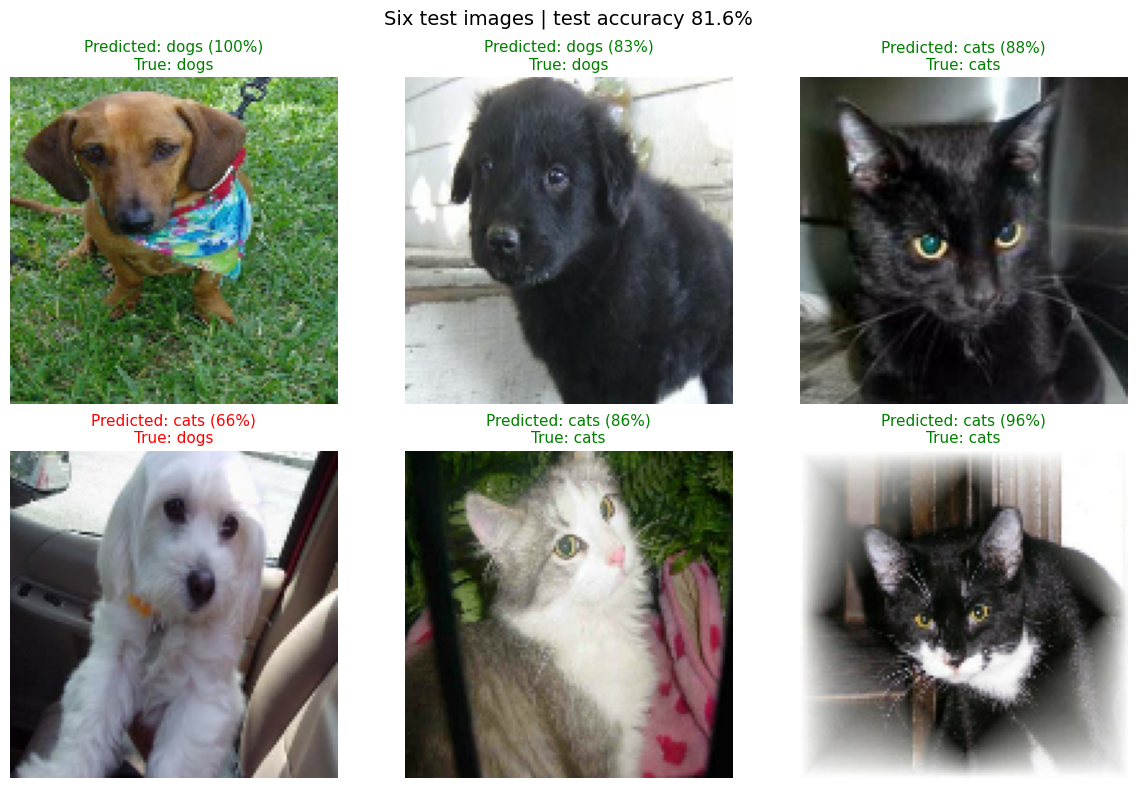


Misclassified: 920 of 5000


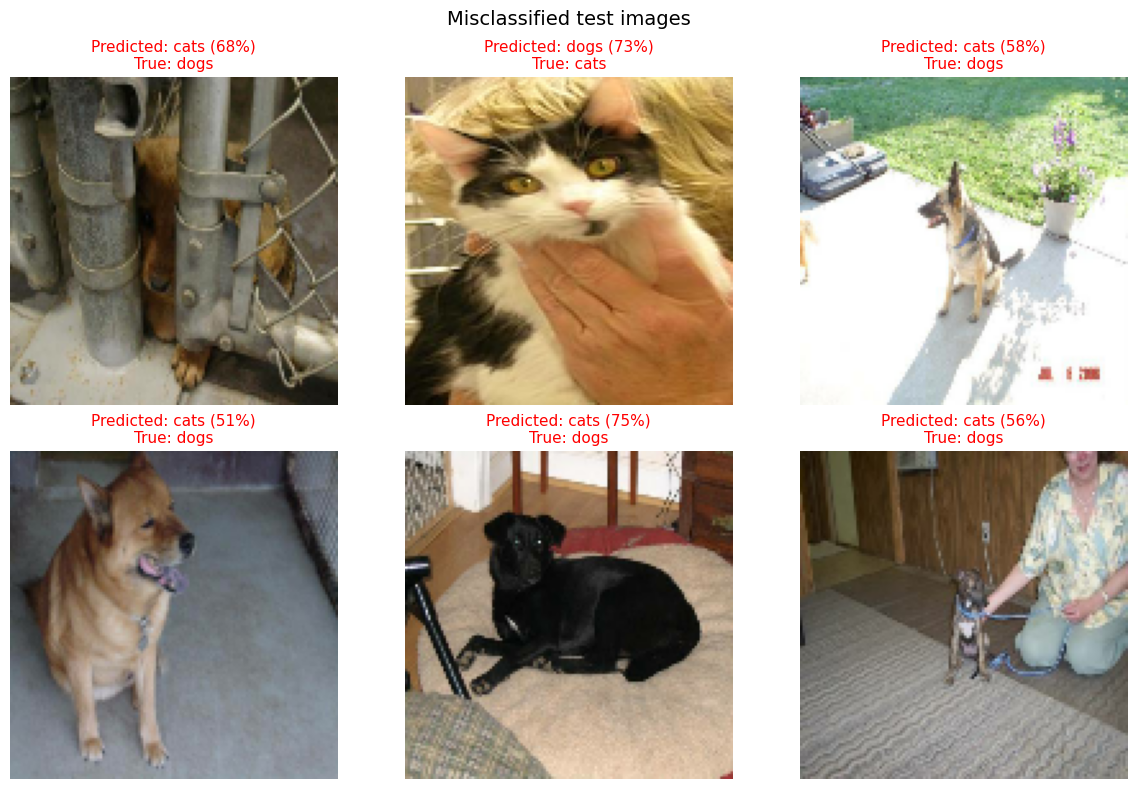

Saved: catsdogs_cnn.keras


In [1]:
import os
 
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
 
# ----------------------------- Configuration -----------------------------
SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5            # use 3 if short on time
N_SAMPLES = 6         # images shown in the labelled figure
AUTOTUNE = tf.data.AUTOTUNE
 
tf.keras.utils.set_random_seed(SEED)
 
 
# ------------------------------ Data loading -----------------------------
def locate_dataset():
    """Return (train_dir, test_dir) wherever the dataset is mounted."""
    roots = ["/kaggle/input", "."]
    for root in roots:
        for current, dirs, _ in os.walk(root):
            if "train" in dirs and "test" in dirs:
                train, test = (os.path.join(current, d) for d in ("train", "test"))
                if (os.path.isdir(os.path.join(train, "cats"))
                        and os.path.isdir(os.path.join(test, "cats"))):
                    return train, test
    try:
        import kagglehub  # works on Colab / local machines
 
        folder = kagglehub.dataset_download("")
        for current, dirs, _ in os.walk(folder):
            if "train" in dirs and "test" in dirs:
                return os.path.join(current, "train"), os.path.join(current, "test")
    except Exception as err:
        raise FileNotFoundError(
            "Dogs vs. Cats not found. On Kaggle use '+ Add Input' -> "
            "'salader/dogs-vs-cats'. Elsewhere run: pip install kagglehub"
        ) from err
    raise FileNotFoundError("Dataset folders train/ and test/ were not found.")
 
 
def skip_bad_files(ds):
    """Skip corrupted images instead of crashing mid-training."""
    if hasattr(ds, "ignore_errors"):
        return ds.ignore_errors()
    return ds.apply(tf.data.experimental.ignore_errors())
 
 
def load_split(directory, **kwargs):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory, image_size=IMG_SIZE, batch_size=BATCH_SIZE, **kwargs
    )
    class_names = ds.class_names
    return skip_bad_files(ds).prefetch(AUTOTUNE), class_names
 
 
# --------------------------------- Model ---------------------------------
def build_model():
    """Small CNN. Rescaling + augmentation live INSIDE the model, so raw
    test images can be fed directly and augmentation is only active in training."""
    return models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.Rescaling(1.0 / 255),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),   # 0 = cat, 1 = dog
    ])
 
 
# ------------------------------ Evaluation -------------------------------
def predict_all(model, ds):
    """One pass over the dataset: keeps images, true labels and predictions
    perfectly aligned (safe even if a corrupted file is skipped)."""
    images, truths, probs = [], [], []
    for batch_x, batch_y in ds:
        probs.append(model.predict(batch_x, verbose=0).ravel())
        truths.append(batch_y.numpy().astype(int))
        images.append(batch_x.numpy().astype("uint8"))
    return np.concatenate(images), np.concatenate(truths), np.concatenate(probs)
 
 
def show_grid(images, truths, preds, probs, indices, class_names, title, filename):
    n = len(indices)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, i in zip(axes, indices):
        ax.imshow(images[i])
        correct = preds[i] == truths[i]
        confidence = probs[i] if preds[i] == 1 else 1 - probs[i]
        ax.set_title(
            f"Predicted: {class_names[preds[i]]} ({confidence:.0%})\nTrue: {class_names[truths[i]]}",
            color="green" if correct else "red", fontsize=11,
        )
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
 
 
def main():
    train_dir, test_dir = locate_dataset()
    print("Train dir:", train_dir, "\nTest dir :", test_dir)
 
    # Visualise class balance BEFORE modelling
    names = ["cats", "dogs"]
    counts = [len(os.listdir(os.path.join(train_dir, n))) for n in names]
    plt.bar(["Cats", "Dogs"], counts, color=["#3E7CB1", "#E8A33D"])
    plt.ylabel("Number of Training Images")
    plt.title("Class Balance: Cats vs. Dogs")
    plt.savefig("task2_class_balance.png", dpi=150)
    plt.show()
 
    train_ds, class_names = load_split(train_dir, validation_split=0.2,
                                       subset="training", seed=SEED)
    val_ds, _ = load_split(train_dir, validation_split=0.2,
                           subset="validation", seed=SEED)
    # Test set: never used in training; shuffle=False keeps order stable
    test_ds, test_classes = load_split(test_dir, shuffle=False)
    assert class_names == test_classes == ["cats", "dogs"], "Class folders mismatch"
 
    model = build_model()
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()
    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
 
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    print(f"\nValidation accuracy: {val_acc:.2%}")
 
    # ---- Task 2: evaluate on the unseen test folder ----
    images, truths, probs = predict_all(model, test_ds)
    preds = (probs > 0.5).astype(int)
    test_accuracy = float(np.mean(preds == truths))
    print(f"TEST ACCURACY ({len(truths)} unseen images): {test_accuracy:.2%}")
 
    # Confusion matrix (rows = true, cols = predicted)
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(truths, preds):
        cm[t, p] += 1
    print("\nConfusion matrix (rows = true, columns = predicted)")
    print(f"            pred cat  pred dog")
    print(f"true cat    {cm[0, 0]:>8}  {cm[0, 1]:>8}")
    print(f"true dog    {cm[1, 0]:>8}  {cm[1, 1]:>8}")
 
    # Six random test images with predicted vs. true labels
    rng = np.random.default_rng(SEED)
    sample = rng.choice(len(truths), size=min(N_SAMPLES, len(truths)), replace=False)
    show_grid(images, truths, preds, probs, sample, class_names,
              f"Six test images | test accuracy {test_accuracy:.1%}",
              "task2_six_test_samples.png")
 
    # Misclassified images, to study the error pattern
    wrong = np.where(preds != truths)[0]
    print(f"\nMisclassified: {len(wrong)} of {len(truths)}")
    if len(wrong) > 0:
        shown = rng.choice(wrong, size=min(6, len(wrong)), replace=False)
        show_grid(images, truths, preds, probs, shown, class_names,
                  "Misclassified test images", "task2_misclassified.png")
 
    model.save("catsdogs_cnn.keras")
    print("Saved: catsdogs_cnn.keras")
 
 
if __name__ == "__main__":
    main()